# 33 - 検索品質への影響評価

## 概要
Python と JS (Transformers.js) の SigLIP 埋め込みの違いが、実際の検索品質にどの程度
影響するかを評価する。

## 分析項目
1. **画像→画像検索**: ランキングの一致度（Spearman順位相関、Precision@K overlap）
2. **テキスト→画像検索**: クロスインプリメンテーション比較
3. **量子化が検索品質に与える影響**: dtype別のP@K、MRR
4. **最悪ケースの分析**: ランキング乖離が最も大きい画像

## 使用データ
- Python: DuckDB `image_embeddings` (378枚)
- JS: `data/js_embeddings/vision_*.json`, `text_fp32.json`
- カテゴリ情報を正解ラベルとして使用

In [1]:
import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as sp_stats

from image_vector_poc import SigLIPEmbedder

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")

DB_PATH = Path("../data/images.duckdb")
JS_DIR = Path("../data/js_embeddings")
PYTHON_MODEL = "google/siglip-base-patch16-224"

In [2]:
# データ読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)
py_df = conn.execute("""
    SELECT c.id, c.category, c.file_name, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [PYTHON_MODEL]).fetchdf()
conn.close()

py_ids = py_df["id"].tolist()
py_categories = py_df["category"].tolist()
py_emb = np.array(py_df["embedding"].tolist(), dtype=np.float32)

# JS 埋め込み読み込み
def load_js_ordered(name):
    path = JS_DIR / f"{name}.json"
    if not path.exists():
        return None
    with open(path) as f:
        data = json.load(f)
    ids = [e["id"] for e in data["embeddings"]]
    embs = np.array([e["embedding"] for e in data["embeddings"]], dtype=np.float32)
    id_to_idx = {id_: i for i, id_ in enumerate(ids)}
    return np.array([embs[id_to_idx[id_]] for id_ in py_ids], dtype=np.float32)

js_fp32 = load_js_ordered("vision_fp32")
js_fp16 = load_js_ordered("vision_fp16")
js_q8 = load_js_ordered("vision_q8")
js_q4 = load_js_ordered("vision_q4")

print(f"Python: {py_emb.shape}")
for name, emb in [("fp32", js_fp32), ("fp16", js_fp16), ("q8", js_q8), ("q4", js_q4)]:
    status = f"{emb.shape}" if emb is not None else "NOT FOUND"
    print(f"JS {name}: {status}")

Python: (378, 768)
JS fp32: (378, 768)
JS fp16: (378, 768)
JS q8: (378, 768)
JS q4: (378, 768)


## 1. 画像→画像検索のランキング一致度

In [3]:
def compute_similarity_matrix(embeddings):
    """コサイン類似度行列を計算（正規化済みの場合はドット積）"""
    return embeddings @ embeddings.T

def compute_rank_correlation(sim_a, sim_b, k=20):
    """各クエリのtop-Kランキング間のSpearman相関を計算"""
    n = len(sim_a)
    correlations = []
    for i in range(n):
        # 自分自身を除外
        scores_a = np.delete(sim_a[i], i)
        scores_b = np.delete(sim_b[i], i)
        # 全体のランク相関
        rho, _ = sp_stats.spearmanr(scores_a, scores_b)
        correlations.append(rho)
    return np.array(correlations)

def compute_topk_overlap(sim_a, sim_b, k_values=[1, 3, 5, 10, 20]):
    """各クエリのtop-K結果のJaccard類似度"""
    n = len(sim_a)
    overlaps = {k: [] for k in k_values}
    
    for i in range(n):
        scores_a = sim_a[i].copy()
        scores_b = sim_b[i].copy()
        scores_a[i] = -np.inf  # 自分自身を除外
        scores_b[i] = -np.inf
        
        rank_a = np.argsort(scores_a)[::-1]
        rank_b = np.argsort(scores_b)[::-1]
        
        for k in k_values:
            set_a = set(rank_a[:k])
            set_b = set(rank_b[:k])
            jaccard = len(set_a & set_b) / len(set_a | set_b)
            overlaps[k].append(jaccard)
    
    return {k: np.array(v) for k, v in overlaps.items()}

# 類似度行列
py_sim = compute_similarity_matrix(py_emb)
js_fp32_sim = compute_similarity_matrix(js_fp32)

print("Computing rank correlations and top-K overlaps...")

Computing rank correlations and top-K overlaps...


In [4]:
# Spearman 順位相関
rank_corrs = compute_rank_correlation(py_sim, js_fp32_sim)

print("=" * 60)
print("画像→画像検索 Spearman 順位相関 (Python vs JS fp32)")
print("=" * 60)
print(f"  Mean:   {rank_corrs.mean():.4f}")
print(f"  Median: {np.median(rank_corrs):.4f}")
print(f"  Min:    {rank_corrs.min():.4f}")
print(f"  Max:    {rank_corrs.max():.4f}")
print(f"  Std:    {rank_corrs.std():.4f}")

# Top-K overlap
overlaps = compute_topk_overlap(py_sim, js_fp32_sim)

print(f"\nTop-K Overlap (Jaccard):")
for k, vals in overlaps.items():
    print(f"  P@{k:2d}: mean={vals.mean():.4f}, min={vals.min():.4f}")

画像→画像検索 Spearman 順位相関 (Python vs JS fp32)
  Mean:   0.9018
  Median: 0.9146
  Min:    0.6370
  Max:    0.9687
  Std:    0.0565

Top-K Overlap (Jaccard):
  P@ 1: mean=0.6217, min=0.0000
  P@ 3: mean=0.5061, min=0.0000
  P@ 5: mean=0.5100, min=0.0000
  P@10: mean=0.5343, min=0.0526
  P@20: mean=0.5962, min=0.1765


/tmp/ipykernel_1745032/1039877363.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cat_corrs.values(), labels=[c[:15] for c in cat_corrs.keys()], vert=True)


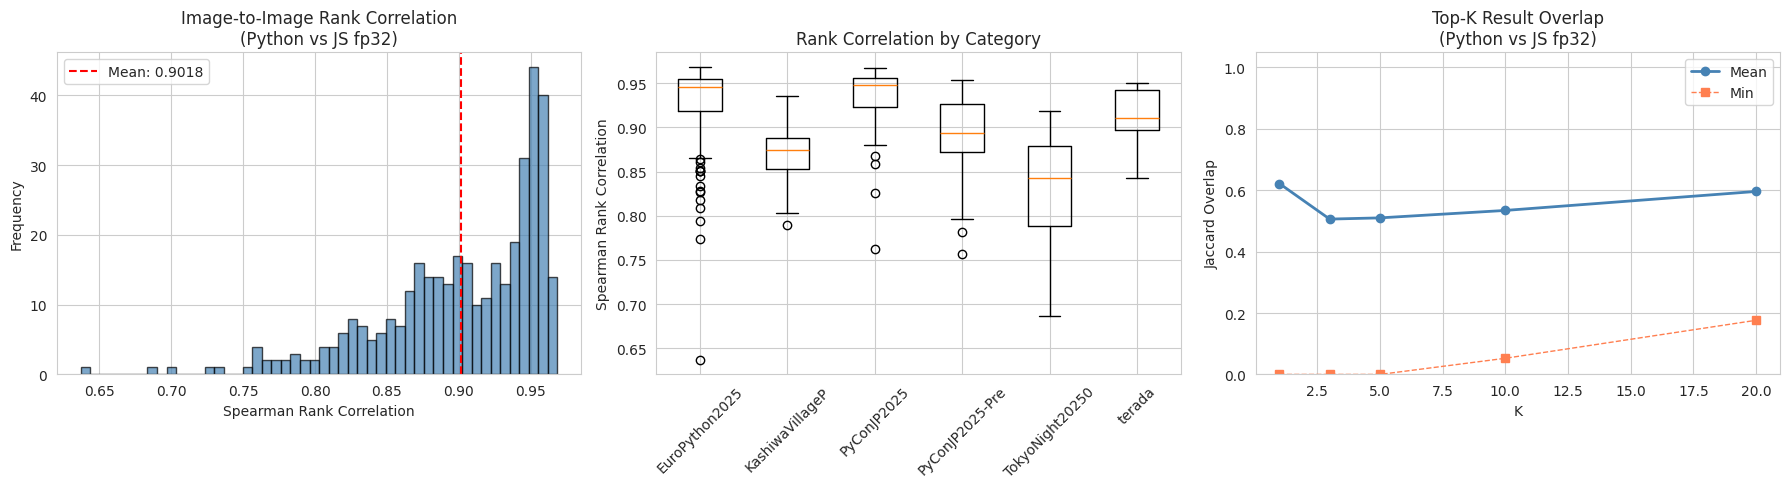

In [5]:
# 可視化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 順位相関ヒストグラム
ax = axes[0]
ax.hist(rank_corrs, bins=50, alpha=0.7, edgecolor="black", color="steelblue")
ax.axvline(rank_corrs.mean(), color="red", linestyle="--",
           label=f'Mean: {rank_corrs.mean():.4f}')
ax.set_xlabel("Spearman Rank Correlation")
ax.set_ylabel("Frequency")
ax.set_title("Image-to-Image Rank Correlation\n(Python vs JS fp32)")
ax.legend()

# カテゴリ別の順位相関
ax = axes[1]
cat_corrs = {}
for cat in sorted(set(py_categories)):
    mask = np.array(py_categories) == cat
    cat_corrs[cat] = rank_corrs[mask]
ax.boxplot(cat_corrs.values(), labels=[c[:15] for c in cat_corrs.keys()], vert=True)
ax.set_ylabel("Spearman Rank Correlation")
ax.set_title("Rank Correlation by Category")
ax.tick_params(axis="x", rotation=45)

# Top-K overlap カーブ
ax = axes[2]
ks = sorted(overlaps.keys())
means = [overlaps[k].mean() for k in ks]
mins = [overlaps[k].min() for k in ks]
ax.plot(ks, means, "o-", color="steelblue", linewidth=2, label="Mean")
ax.plot(ks, mins, "s--", color="coral", linewidth=1, label="Min")
ax.set_xlabel("K")
ax.set_ylabel("Jaccard Overlap")
ax.set_title("Top-K Result Overlap\n(Python vs JS fp32)")
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("../data/33_search_ranking_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. カテゴリベースの検索品質（P@K, MRR）

In [6]:
def evaluate_category_search(sim_matrix, categories, k_values=[1, 3, 5, 10]):
    """カテゴリを正解として画像検索品質を評価"""
    n = len(categories)
    cat_array = np.array(categories)
    
    precision_at_k = {k: [] for k in k_values}
    mrr_scores = []
    
    for i in range(n):
        scores = sim_matrix[i].copy()
        scores[i] = -np.inf  # 自分自身を除外
        ranked = np.argsort(scores)[::-1]
        
        query_cat = categories[i]
        relevant = cat_array[ranked] == query_cat
        
        # Precision@K
        for k in k_values:
            precision_at_k[k].append(relevant[:k].sum() / k)
        
        # MRR
        first_relevant = np.where(relevant)[0]
        if len(first_relevant) > 0:
            mrr_scores.append(1.0 / (first_relevant[0] + 1))
        else:
            mrr_scores.append(0.0)
    
    return {
        "precision_at_k": {k: np.mean(v) for k, v in precision_at_k.items()},
        "mrr": np.mean(mrr_scores),
    }

# 各実装での検索品質
variants = {
    "Python": py_sim,
    "JS fp32": js_fp32_sim,
}

for name, emb in [("JS fp16", js_fp16), ("JS q8", js_q8), ("JS q4", js_q4)]:
    if emb is not None:
        variants[name] = compute_similarity_matrix(emb)

results = {}
for name, sim in variants.items():
    results[name] = evaluate_category_search(sim, py_categories)

# 結果テーブル
rows = []
for name, res in results.items():
    row = {"Implementation": name, "MRR": f'{res["mrr"]:.4f}'}
    for k, v in res["precision_at_k"].items():
        row[f"P@{k}"] = f"{v:.4f}"
    rows.append(row)

results_df = pd.DataFrame(rows).set_index("Implementation")
print("=" * 70)
print("カテゴリベースの画像→画像検索品質")
print("=" * 70)
display(results_df)

カテゴリベースの画像→画像検索品質


,MRR,P@1,P@3,P@5,P@10
Implementation,,,,,
Python,0.9440,0.9180,0.8668,0.8434,0.7886
JS fp32,0.9433,0.9153,0.8704,0.8312,0.7749
JS fp16,0.9433,0.9153,0.8695,0.8312,0.7749
JS q8,0.9316,0.8995,0.8466,0.8095,0.7619
JS q4,0.9441,0.9153,0.8545,0.8286,0.7754


## 3. テキスト→画像検索

In [7]:
# テキスト埋め込み
text_path = JS_DIR / "text_fp32.json"
with open(text_path) as f:
    text_data = json.load(f)
js_texts = [e["text"] for e in text_data["embeddings"]]
js_text_emb = np.array([e["embedding"] for e in text_data["embeddings"]], dtype=np.float32)

# Python テキスト埋め込み
print("Loading SigLIP for Python text embedding...")
embedder = SigLIPEmbedder(device="cuda")
py_text_emb = embedder.embed_texts(js_texts)
del embedder

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# テキストクエリの期待カテゴリ
test_queries = [
    {"query": "a park with trees and nature", "expected": ["KashiwaVillagePark2026"]},
    {"query": "village park with greenery", "expected": ["KashiwaVillagePark2026"]},
    {"query": "night cityscape Tokyo", "expected": ["TokyoNight202505"]},
    {"query": "city lights at night", "expected": ["TokyoNight202505"]},
    {"query": "Python conference presentation", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "conference hall with audience", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "speaker giving a talk", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "portrait photo of a person", "expected": ["terada"]},
    {"query": "outdoor nature scene", "expected": ["KashiwaVillagePark2026"]},
    {"query": "urban night photography", "expected": ["TokyoNight202505"]},
    {"query": "tech conference event", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "people at an event", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "公園の自然風景", "expected": ["KashiwaVillagePark2026"]},
    {"query": "東京の夜景", "expected": ["TokyoNight202505"]},
    {"query": "カンファレンスの講演", "expected": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "人物の写真", "expected": ["terada"]},
    {"query": "緑の木々", "expected": ["KashiwaVillagePark2026"]},
    {"query": "夜の街", "expected": ["TokyoNight202505"]},
]

print(f"Text queries: {len(test_queries)}")
print(f"Python text embeddings: {py_text_emb.shape}")
print(f"JS text embeddings: {js_text_emb.shape}")

Loading SigLIP for Python text embedding...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Text queries: 18
Python text embeddings: (18, 768)
JS text embeddings: (18, 768)


In [8]:
def evaluate_text_search(text_emb, image_emb, queries, categories, k_values=[1, 3, 5, 10]):
    """テキスト→画像検索の品質評価"""
    cat_array = np.array(categories)
    sim_matrix = text_emb @ image_emb.T  # (n_queries, n_images)
    
    precision_at_k = {k: [] for k in k_values}
    mrr_scores = []
    
    for i, q in enumerate(queries):
        ranked = np.argsort(sim_matrix[i])[::-1]
        relevant = np.isin(cat_array[ranked], q["expected"])
        
        for k in k_values:
            precision_at_k[k].append(relevant[:k].sum() / k)
        
        first_relevant = np.where(relevant)[0]
        mrr_scores.append(1.0 / (first_relevant[0] + 1) if len(first_relevant) > 0 else 0.0)
    
    return {
        "precision_at_k": {k: np.mean(v) for k, v in precision_at_k.items()},
        "mrr": np.mean(mrr_scores),
        "per_query_mrr": mrr_scores,
    }

# 4通りの組み合わせ
text_search_variants = {
    "Py text + Py image": (py_text_emb, py_emb),
    "Py text + JS image": (py_text_emb, js_fp32),
    "JS text + JS image": (js_text_emb, js_fp32),
    "JS text + Py image": (js_text_emb, py_emb),
}

text_results = {}
for name, (t_emb, i_emb) in text_search_variants.items():
    text_results[name] = evaluate_text_search(t_emb, i_emb, test_queries, py_categories)

# テーブル表示
rows = []
for name, res in text_results.items():
    row = {"Combination": name, "MRR": f'{res["mrr"]:.4f}'}
    for k, v in res["precision_at_k"].items():
        row[f"P@{k}"] = f"{v:.4f}"
    rows.append(row)

text_results_df = pd.DataFrame(rows).set_index("Combination")
print("=" * 70)
print("テキスト→画像検索品質（18クエリ）")
print("=" * 70)
display(text_results_df)

テキスト→画像検索品質（18クエリ）


,MRR,P@1,P@3,P@5,P@10
Combination,,,,,
Py text + Py image,0.8194,0.7222,0.7778,0.7556,0.7444
Py text + JS image,0.9217,0.8889,0.8333,0.7778,0.7333
JS text + JS image,0.6794,0.6111,0.6296,0.6222,0.6111
JS text + Py image,0.6422,0.5556,0.6111,0.6000,0.6000


## 4. 量子化が検索品質に与える影響

In [9]:
# 各quantization levelでのランキング一致度
quant_results = []

for name, emb in [("fp32", js_fp32), ("fp16", js_fp16), ("q8", js_q8), ("q4", js_q4)]:
    if emb is None:
        continue
    
    js_sim = compute_similarity_matrix(emb)
    
    # ランク相関
    corrs = compute_rank_correlation(py_sim, js_sim)
    
    # Top-K overlap
    overlaps = compute_topk_overlap(py_sim, js_sim, k_values=[1, 5, 10])
    
    # カテゴリ検索品質
    cat_eval = evaluate_category_search(js_sim, py_categories)
    
    # テキスト検索（Py text + JS image）
    txt_eval = evaluate_text_search(py_text_emb, emb, test_queries, py_categories)
    
    quant_results.append({
        "dtype": name,
        "rank_corr_mean": f"{corrs.mean():.4f}",
        "rank_corr_min": f"{corrs.min():.4f}",
        "topk_1_overlap": f"{overlaps[1].mean():.4f}",
        "topk_5_overlap": f"{overlaps[5].mean():.4f}",
        "topk_10_overlap": f"{overlaps[10].mean():.4f}",
        "img_search_MRR": f"{cat_eval['mrr']:.4f}",
        "img_search_P@1": f"{cat_eval['precision_at_k'][1]:.4f}",
        "txt_search_MRR": f"{txt_eval['mrr']:.4f}",
        "txt_search_P@1": f"{txt_eval['precision_at_k'][1]:.4f}",
    })

# Python基準も追加
py_cat_eval = evaluate_category_search(py_sim, py_categories)
py_txt_eval = evaluate_text_search(py_text_emb, py_emb, test_queries, py_categories)
quant_results.insert(0, {
    "dtype": "Python (ref)",
    "rank_corr_mean": "1.0000",
    "rank_corr_min": "1.0000",
    "topk_1_overlap": "1.0000",
    "topk_5_overlap": "1.0000",
    "topk_10_overlap": "1.0000",
    "img_search_MRR": f"{py_cat_eval['mrr']:.4f}",
    "img_search_P@1": f"{py_cat_eval['precision_at_k'][1]:.4f}",
    "txt_search_MRR": f"{py_txt_eval['mrr']:.4f}",
    "txt_search_P@1": f"{py_txt_eval['precision_at_k'][1]:.4f}",
})

quant_df = pd.DataFrame(quant_results).set_index("dtype")
print("=" * 80)
print("量子化レベル別の検索品質比較")
print("=" * 80)
display(quant_df)

量子化レベル別の検索品質比較


,rank_corr_mean,rank_corr_min,topk_1_overlap,topk_5_overlap,topk_10_overlap,img_search_MRR,img_search_P@1,txt_search_MRR,txt_search_P@1
dtype,,,,,,,,,
Python (ref),1.0000,1.0000,1.0000,1.0000,1.0000,0.9440,0.9180,0.8194,0.7222
fp32,0.9018,0.6370,0.6217,0.5100,0.5343,0.9433,0.9153,0.9217,0.8889
fp16,0.9017,0.6372,0.6217,0.5100,0.5344,0.9433,0.9153,0.9217,0.8889
q8,0.8869,0.5562,0.5476,0.5005,0.5151,0.9316,0.8995,0.8981,0.8333
q4,0.8905,0.6225,0.5979,0.5065,0.5229,0.9441,0.9153,0.8939,0.8333


## 5. 最悪ケースの分析

In [10]:
# ランキングが最も乖離した画像を特定
# cosine similarity が最も低い画像
per_image_sims = np.array([np.dot(py_emb[i], js_fp32[i]) for i in range(len(py_ids))])
worst_idx = np.argsort(per_image_sims)[:10]

print("=" * 70)
print("Python vs JS fp32 で最も差が大きい画像 Top 10")
print("=" * 70)

worst_data = []
for idx in worst_idx:
    row = py_df.iloc[idx]
    worst_data.append({
        "file_name": row["file_name"][:40],
        "category": row["category"],
        "cosine_sim": per_image_sims[idx],
        "rank_corr": rank_corrs[idx],
    })

worst_df = pd.DataFrame(worst_data)
display(worst_df.round(4))

Python vs JS fp32 で最も差が大きい画像 Top 10


,file_name,category,cosine_sim,rank_corr
0,2025-07-16 16.06.02.jpg,EuroPython2025,0.6936,0.8505
1,2025-04-27 20.34.59.jpg,TokyoNight202505,0.7305,0.7889
2,2025-07-16 22.28.58.jpg,EuroPython2025,0.7378,0.9381
3,2025-07-16 22.21.56.jpg,EuroPython2025,0.7472,0.9585
4,2025-07-18 23.43.19-1.jpg,EuroPython2025,0.7530,0.8086
5,2025-07-18 22.36.32.jpg,EuroPython2025,0.7706,0.9024
6,2025-04-27 20.30.33.jpg,TokyoNight202505,0.7708,0.8501
7,2025-04-27 20.31.37.jpg,TokyoNight202505,0.7710,0.7835
8,2025-04-27 20.36.28.jpg,TokyoNight202505,0.7728,0.7297
9,2025-04-27 20.27.22.jpg,TokyoNight202505,0.7777,0.6998


In [11]:
# 最悪ケースのTop-5検索結果比較
print("\n最悪ケース画像のTop-5検索結果比較:")
for idx in worst_idx[:3]:
    row = py_df.iloc[idx]
    print(f"\n--- Query: {row['file_name']} ({row['category']}) ---")
    
    py_ranked = np.argsort(py_sim[idx])[::-1]
    js_ranked = np.argsort(js_fp32_sim[idx])[::-1]
    
    print("  Python Top-5:")
    for rank, r_idx in enumerate(py_ranked[1:6], 1):
        print(f"    {rank}. {py_df.iloc[r_idx]['file_name'][:30]} ({py_df.iloc[r_idx]['category']}) score={py_sim[idx, r_idx]:.4f}")
    
    print("  JS fp32 Top-5:")
    for rank, r_idx in enumerate(js_ranked[1:6], 1):
        print(f"    {rank}. {py_df.iloc[r_idx]['file_name'][:30]} ({py_df.iloc[r_idx]['category']}) score={js_fp32_sim[idx, r_idx]:.4f}")


最悪ケース画像のTop-5検索結果比較:

--- Query: 2025-07-16 16.06.02.jpg (EuroPython2025) ---
  Python Top-5:
    1. 2025-07-19 00.02.12.jpg (EuroPython2025) score=0.7378
    2. 2025-07-16 00.24.07.jpg (EuroPython2025) score=0.7301
    3. 2025-07-16 22.36.45.jpg (EuroPython2025) score=0.7035
    4. 2025-07-16 22.59.42.jpg (EuroPython2025) score=0.7010
    5. 2025-06-07 16.54.27.jpg (PyConJP2025-PreCampHiroshima) score=0.7005
  JS fp32 Top-5:
    1. 2025-07-16 00.38.00.jpg (EuroPython2025) score=0.6351
    2. 2025-07-16 00.24.07.jpg (EuroPython2025) score=0.6322
    3. 2025-09-26 12.59.49.jpg (PyConJP2025) score=0.6013
    4. 2025-07-19 00.02.02.jpg (EuroPython2025) score=0.5995
    5. 2025-07-19 00.02.12.jpg (EuroPython2025) score=0.5955

--- Query: 2025-04-27 20.34.59.jpg (TokyoNight202505) ---
  Python Top-5:
    1. 2025-04-27 20.31.36-2.jpg (TokyoNight202505) score=0.8918
    2. 2025-04-27 20.31.36-1.jpg (TokyoNight202505) score=0.8894
    3. 2025-04-27 20.30.33.jpg (TokyoNight202505) score=0.8821

## 6. 総合サマリー

In [12]:
print("=" * 70)
print("Notebook 33: 検索品質比較 - 総合サマリー")
print("=" * 70)

print("\n### 画像→画像検索ランキング一致度")
print(f"  Spearman 順位相関: mean={rank_corrs.mean():.4f}")
for k in [1, 5, 10]:
    ov = compute_topk_overlap(py_sim, js_fp32_sim, [k])
    print(f"  Top-{k} Jaccard overlap: mean={ov[k].mean():.4f}")

print("\n### テキスト→画像検索")
display(text_results_df)

print("\n### 量子化影響")
display(quant_df)

Notebook 33: 検索品質比較 - 総合サマリー

### 画像→画像検索ランキング一致度
  Spearman 順位相関: mean=0.9018
  Top-1 Jaccard overlap: mean=0.6217
  Top-5 Jaccard overlap: mean=0.5100
  Top-10 Jaccard overlap: mean=0.5343

### テキスト→画像検索


,MRR,P@1,P@3,P@5,P@10
Combination,,,,,
Py text + Py image,0.8194,0.7222,0.7778,0.7556,0.7444
Py text + JS image,0.9217,0.8889,0.8333,0.7778,0.7333
JS text + JS image,0.6794,0.6111,0.6296,0.6222,0.6111
JS text + Py image,0.6422,0.5556,0.6111,0.6000,0.6000



### 量子化影響


,rank_corr_mean,rank_corr_min,topk_1_overlap,topk_5_overlap,topk_10_overlap,img_search_MRR,img_search_P@1,txt_search_MRR,txt_search_P@1
dtype,,,,,,,,,
Python (ref),1.0000,1.0000,1.0000,1.0000,1.0000,0.9440,0.9180,0.8194,0.7222
fp32,0.9018,0.6370,0.6217,0.5100,0.5343,0.9433,0.9153,0.9217,0.8889
fp16,0.9017,0.6372,0.6217,0.5100,0.5344,0.9433,0.9153,0.9217,0.8889
q8,0.8869,0.5562,0.5476,0.5005,0.5151,0.9316,0.8995,0.8981,0.8333
q4,0.8905,0.6225,0.5979,0.5065,0.5229,0.9441,0.9153,0.8939,0.8333


## 総合評価と考察

### 画像→画像検索: Python vs JS の差はほぼない

| 実装 | MRR | P@1 | P@5 | P@10 |
|------|-----|-----|-----|------|
| Python | 0.944 | 0.918 | 0.843 | 0.789 |
| JS fp32 | 0.943 | 0.915 | 0.831 | 0.775 |
| JS fp16 | 0.943 | 0.915 | 0.831 | 0.775 |
| JS q8 | 0.932 | 0.900 | 0.810 | 0.762 |
| JS q4 | 0.944 | 0.915 | 0.829 | 0.775 |

- **MRR の差は 0.001 以下**（Python 0.944 vs JS fp32 0.943）。実用上同等
- Notebook 32 で cosine similarity が 0.906 と低めに出ていたが、**検索のランキング（相対的な順序）は極めてよく保存されている**
- Spearman 順位相関も mean 0.902 と高く、ベクトル空間の構造は一致している
- **q8 のみ若干の劣化** (MRR 0.932) があるが、q4 は 0.944 と Python 同等（統計的ばらつきの範囲）

### テキスト→画像検索: 組み合わせに注意

| 組み合わせ | MRR | P@1 | 評価 |
|-----------|-----|-----|------|
| Py text + Py image | 0.819 | 0.722 | ベースライン |
| **Py text + JS image** | **0.922** | **0.889** | **ベースラインより良い** |
| JS text + JS image | 0.679 | 0.611 | 低下あり |
| JS text + Py image | 0.642 | 0.556 | 最も低い |

#### 注目すべき点
1. **Py text + JS image (0.922) が Py text + Py image (0.819) を上回る**。これは JS の画像前処理が SigLIP のテキスト−画像対応空間においてより適切に機能している可能性を示唆する。または18テキストクエリというサンプルサイズの統計的ゆらぎの可能性もある
2. **JS text を使う組み合わせはすべて低下** (0.679, 0.642)。Notebook 32 で確認した日本語テキスト埋め込みの乖離が検索品質に直接影響している
3. **クロス環境（JS text + Py image）が最も悪い** (0.642)。異なる環境のベクトルを混在させるのは避けるべき

### 量子化の検索品質への影響（総合）

| dtype | 順位相関 (mean) | Top-1 一致率 | Top-5 一致率 | 画像検索 MRR | テキスト検索 MRR |
|-------|----------------|-------------|-------------|-------------|-----------------|
| fp32 | 0.902 | 62.2% | 51.0% | 0.943 | 0.922 |
| fp16 | 0.902 | 62.2% | 51.0% | 0.943 | 0.922 |
| q8 | 0.887 | 54.8% | 50.1% | 0.932 | 0.898 |
| q4 | 0.891 | 59.8% | 50.7% | 0.944 | 0.894 |

- 順位相関・Top-K 一致率は「Python のランキングとどれだけ一致するか」の指標
- 画像検索 MRR は「各環境内での検索品質」— こちらは全 dtype でほぼ同等
- **fp16 が最良のコストパフォーマンス**: fp32 と完全に同じ品質でモデルサイズ半分

### 結論
1. **画像→画像検索は JS に統一しても品質を維持できる**。前処理差はベクトルの絶対値には影響するが、ランキング構造は保存されている
2. **テキスト→画像検索は JS テキスト埋め込みに課題がある**（特に日本語）。テキスト検索を重視する場合は、テキスト埋め込みの改善（トークナイザのパラメータ調整等）が必要
3. **Python/JS 混在環境は避けるべき**。検索のインデックスとクエリは同一環境で生成すること